# Binary Classification Project

This is example of me understanding binary classification in python

Imported libraries needed and the data sets that will be used in this project. 

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
attrition_past = pd.read_csv('https://bradfordtuckfield.com/attrition_past.csv')
attrition_future = pd.read_csv('https://bradfordtuckfield.com/attrition2.csv')

## EDA

In [3]:
attrition_past.describe()

,lastmonth_activity,lastyear_activity,number_of_employees,exited
count,26.000000,26.000000,26.000000,26.000000
mean,165.653846,1502.923077,26.884615,0.576923
std,284.033229,2192.644958,31.353886,0.503831
min,0.000000,18.000000,1.000000,0.000000
25%,16.750000,406.250000,7.250000,0.000000
50%,73.000000,955.000000,14.000000,1.000000
75%,100.750000,1615.500000,34.500000,1.000000
max,1090.000000,10983.000000,103.000000,1.000000


In [4]:
attrition_past.head()

,corporation,lastmonth_activity,lastyear_activity,number_of_employees,exited
0,abcd,78,1024,12,1
1,asdf,14,2145,20,0
2,xyzz,182,3891,35,0
3,acme,101,10983,2,1
4,qwer,0,118,42,1


For a quick EDA, you can see that the mean for the last month's activity was 0.58 for exiting. This means there is something interesting going on with the last month's activity. 

### Visualizations

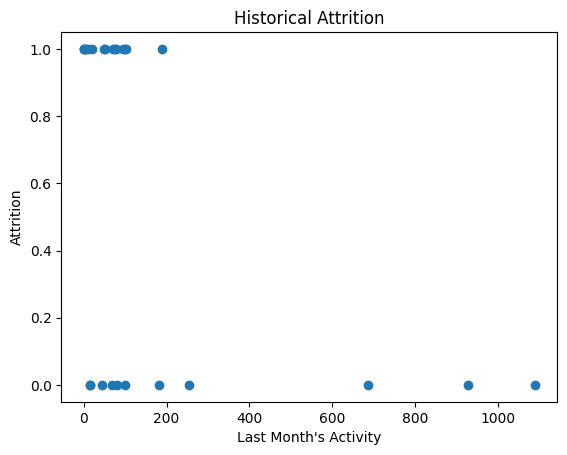

In [2]:
plt.scatter(attrition_past['lastmonth_activity'],attrition_past['exited'])
plt.title('Historical Attrition')
plt.xlabel('Last Month\'s Activity')
plt.ylabel('Attrition')
plt.show()

## Linear Regression

In [3]:
x = attrition_past['lastmonth_activity'].values.reshape(-1,1)
y = attrition_past['exited'].values.reshape(-1,1)

regressor = LinearRegression()
regressor.fit(x,y)

LinearRegression()

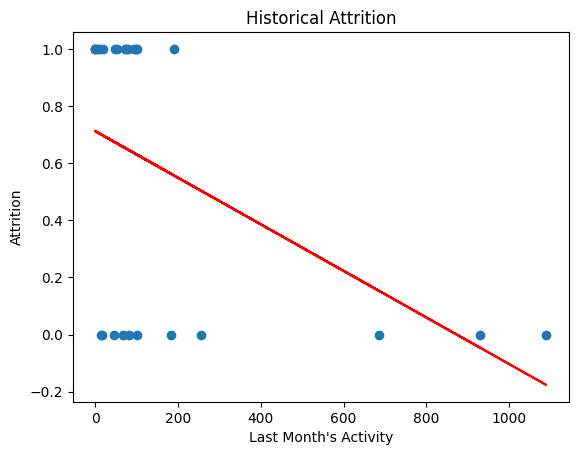

In [4]:
plt.scatter(attrition_past['lastmonth_activity'],attrition_past['exited'])
prediction = [regressor.coef_[0]*x+regressor.intercept_[0] for x in list(attrition_past['lastmonth_activity'])]
plt.plot(attrition_past['lastmonth_activity'],prediction,color='red')
plt.title('Historical Attrition')
plt.xlabel('Last Month\'s Activity')
plt.ylabel('Attrition')
plt.show()

In [5]:
attrition_past['predicted'] = regressor.predict(x)

In [6]:
attrition_past.head()

,corporation,lastmonth_activity,lastyear_activity,number_of_employees,exited,predicted
0,abcd,78,1024,12,1,0.648363
1,asdf,14,2145,20,0,0.700525
2,xyzz,182,3891,35,0,0.563600
3,acme,101,10983,2,1,0.629618
4,qwer,0,118,42,1,0.711936


Using the linear regression from the given known values. You now can see the predicted probability value for someone to exit this business. For example, you can see with 400 Activity there is around a 40% chance that someone would exit. This can be used to predict future value. 

## Predicting Future Values

In [7]:
x = attrition_future['lastmonth_activity'].values.reshape(-1,1)
attrition_future['predicted'] = regressor.predict(x)

In [9]:
attrition_future.head()

,corporation,lastmonth_activity,lastyear_activity,number_of_employees,predicted
0,hhtn,166,1393,91,0.576641
1,slfm,824,16920,288,0.040352
2,pryr,68,549,12,0.656514
3,ahva,121,1491,16,0.613317
4,dmai,4,94,2,0.708676


In [10]:
print(attrition_future.nlargest(5,'predicted'))

   corporation  lastmonth_activity  lastyear_activity  number_of_employees  \
8         whsh                   0                 40                   52   
12        mike                   0                  0                   49   
24        pian                   0                 12                   19   
21        bass                   2                 19                 1400   
4         dmai                   4                 94                    2   

    predicted  
8    0.711936  
12   0.711936  
24   0.711936  
21   0.710306  
4    0.708676  


In [11]:
print(list(attrition_future.sort_values(by='predicted',ascending=False).loc[:,'corporation']))

['whsh', 'pian', 'mike', 'bass', 'pevc', 'dmai', 'ynus', 'kdic', 'hlpd', 'angl', 'erin', 'oscr', 'grce', 'zamk', 'hlly', 'xkcd', 'dwgt', 'pryr', 'skct', 'frgv', 'ejdc', 'ahva', 'wlcj', 'hhtn', 'slfm', 'cred']


In [12]:
print(list(attrition_future.loc[attrition_future['predicted']>0.7,'corporation']))

['dmai', 'whsh', 'oscr', 'kdic', 'mike', 'pevc', 'erin', 'angl', 'bass', 'ynus', 'pian', 'hlpd']


In [13]:
median = attrition_past['predicted'].median()
prediction = list(1*(attrition_past['predicted']>median))
actual = list(attrition_past['exited'])